In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import ML libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for traditional ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Preprocessing and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

# For image processing
import cv2
from skimage.feature import hog, local_binary_pattern
from skimage import exposure

print("All libraries imported successfully!")

Mounted at /content/drive
All libraries imported successfully!


In [2]:
# Load CIFAR-10
from tensorflow.keras.datasets import cifar10
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Original image shape: {train_images[0].shape}")
print(f"Training images: {train_images.shape}")
print(f"Test images: {test_images.shape}")

# For traditional ML, we need to flatten images (convert 2D to 1D)
# Each 32x32x3 image becomes 3072 features (32*32*3)
X_train_flat = train_images.reshape(train_images.shape[0], -1)
X_test_flat = test_images.reshape(test_images.shape[0], -1)

# Flatten labels
y_train = train_labels.ravel()
y_test = test_labels.ravel()

print(f"\nAfter flattening:")
print(f"Training features shape: {X_train_flat.shape} (50000 images, 3072 features each)")
print(f"Test features shape: {X_test_flat.shape}")

# Create smaller subset for faster training (since ML is slower on big data)
# Use 10,000 images for training instead of 50,000
X_train_small = X_train_flat[:10000]
y_train_small = y_train[:10000]
X_test_small = X_test_flat[:2000]
y_test_small = y_test[:2000]

print(f"\nUsing smaller subset for faster training:")
print(f"Training: {X_train_small.shape}")
print(f"Testing: {X_test_small.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Original image shape: (32, 32, 3)
Training images: (50000, 32, 32, 3)
Test images: (10000, 32, 32, 3)

After flattening:
Training features shape: (50000, 3072) (50000 images, 3072 features each)
Test features shape: (10000, 3072)

Using smaller subset for faster training:
Training: (10000, 3072)
Testing: (2000, 3072)


In [3]:
# Function to extract HOG features (Histogram of Oriented Gradients)
def extract_hog_features(images):
    hog_features = []
    for img in images:
        # Reshape back to 32x32x3
        img_reshaped = img.reshape(32, 32, 3)
        # Convert to grayscale
        gray = cv2.cvtColor(img_reshaped, cv2.COLOR_RGB2GRAY)
        # Extract HOG features
        features = hog(gray, orientations=9, pixels_per_cell=(4, 4),
                       cells_per_block=(2, 2), feature_vector=True)
        hog_features.append(features)
    return np.array(hog_features)

# Function to extract color histograms
def extract_color_features(images):
    color_features = []
    for img in images:
        img_reshaped = img.reshape(32, 32, 3)
        # Calculate histograms for each color channel
        hist_r = np.histogram(img_reshaped[:,:,0], bins=32, range=(0, 256))[0]
        hist_g = np.histogram(img_reshaped[:,:,1], bins=32, range=(0, 256))[0]
        hist_b = np.histogram(img_reshaped[:,:,2], bins=32, range=(0, 256))[0]
        # Concatenate histograms
        features = np.concatenate([hist_r, hist_g, hist_b])
        color_features.append(features)
    return np.array(color_features)

# Extract features (this might take 2-3 minutes)
print("Extracting HOG features...")
X_train_hog = extract_hog_features(X_train_small)
X_test_hog = extract_hog_features(X_test_small)

print("Extracting color features...")
X_train_color = extract_color_features(X_train_small)
X_test_color = extract_color_features(X_test_small)

# Combine all features
X_train_features = np.hstack([X_train_hog, X_train_color])
X_test_features = np.hstack([X_test_hog, X_test_color])

print(f"\nFinal feature set shape: {X_train_features.shape}")
print(f"Total features per image: {X_train_features.shape[1]}")

Extracting HOG features...
Extracting color features...

Final feature set shape: (10000, 1860)
Total features per image: 1860


In [4]:
# Scale features (ML algorithms perform better with scaled data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

print("Features scaled successfully!")
print(f"Mean after scaling: {X_train_scaled.mean():.2f}")
print(f"Std after scaling: {X_train_scaled.std():.2f}")

Features scaled successfully!
Mean after scaling: -0.00
Std after scaling: 1.00


In [5]:
# Reduce dimensions for faster training
pca = PCA(n_components=100)  # Reduce to 100 features
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"After PCA: {X_train_pca.shape}")
print(f"Variance retained: {sum(pca.explained_variance_ratio_):.2%}")

After PCA: (10000, 100)
Variance retained: 46.63%


In [6]:
# CREATE ALL ML MODELS
print("Creating machine learning models...")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'SVM (Linear)': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

print("✅ Models ready:")
for name in models.keys():
    print(f"  • {name}")

Creating machine learning models...
✅ Models ready:
  • Random Forest
  • SVM (RBF)
  • SVM (Linear)
  • KNN
  • Logistic Regression
  • Decision Tree


In [7]:
# TRAIN ALL MODELS
import time

results = {}
predictions = {}
training_times = {}

print("="*60)
print("🚀 STARTING MODEL TRAINING")
print("="*60)
print("This will take 15-20 minutes. Go grab a coffee! ☕")
print("="*60)

for name, model in models.items():
    print(f"\n▶️ Training {name}...")
    print("-"*40)

    # Start timer
    start_time = time.time()

    # Train the model
    model.fit(X_train_pca, y_train_small)

    # Calculate training time
    training_time = time.time() - start_time

    # Make predictions
    y_pred = model.predict(X_test_pca)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_small, y_pred)

    # Store results
    results[name] = accuracy
    predictions[name] = y_pred
    training_times[name] = training_time

    print(f"✅ Accuracy: {accuracy*100:.2f}%")
    print(f"⏱️  Time: {training_time:.2f} seconds")

print("\n" + "="*60)
print("🎉 TRAINING COMPLETE!")
print("="*60)

🚀 STARTING MODEL TRAINING
This will take 15-20 minutes. Go grab a coffee! ☕

▶️ Training Random Forest...
----------------------------------------
✅ Accuracy: 45.65%
⏱️  Time: 30.56 seconds

▶️ Training SVM (RBF)...
----------------------------------------
✅ Accuracy: 57.60%
⏱️  Time: 15.26 seconds

▶️ Training SVM (Linear)...
----------------------------------------
✅ Accuracy: 49.25%
⏱️  Time: 369.00 seconds

▶️ Training KNN...
----------------------------------------
✅ Accuracy: 45.70%
⏱️  Time: 0.01 seconds

▶️ Training Logistic Regression...
----------------------------------------
✅ Accuracy: 49.55%
⏱️  Time: 1.92 seconds

▶️ Training Decision Tree...
----------------------------------------
✅ Accuracy: 25.65%
⏱️  Time: 2.58 seconds

🎉 TRAINING COMPLETE!


In [8]:
# VIEW RESULTS
# Create results dataframe
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy (%)': [acc*100 for acc in results.values()],
    'Training Time (s)': list(training_times.values())
})
results_df = results_df.sort_values('Accuracy (%)', ascending=False)

print("\n" + "="*70)
print("📊 MODEL PERFORMANCE RANKING")
print("="*70)
print(results_df.to_string(index=False))

# Find best model
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy (%)']
print(f"\n🏆 WINNER: {best_model_name} with {best_accuracy:.2f}% accuracy")


📊 MODEL PERFORMANCE RANKING
              Model  Accuracy (%)  Training Time (s)
          SVM (RBF)         57.60          15.262969
Logistic Regression         49.55           1.918019
       SVM (Linear)         49.25         369.003226
                KNN         45.70           0.007800
      Random Forest         45.65          30.561343
      Decision Tree         25.65           2.576304

🏆 WINNER: SVM (RBF) with 57.60% accuracy


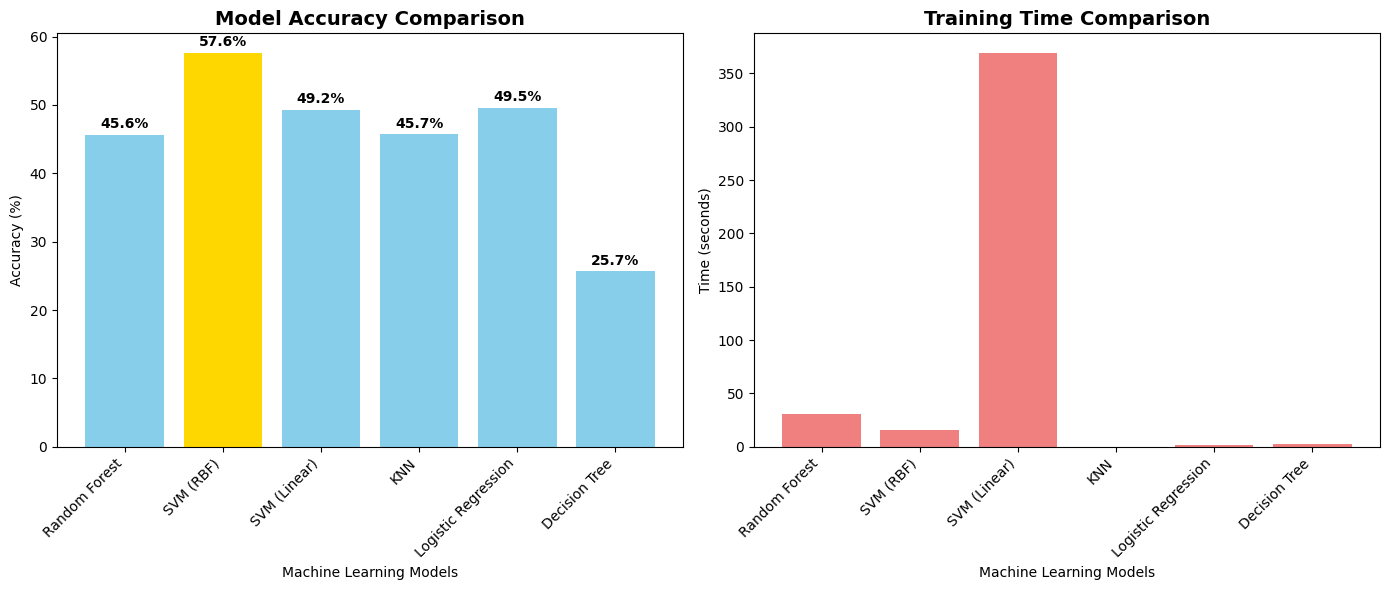

✅ Chart saved to Google Drive


In [9]:
# CREATE COMPARISON CHART
plt.figure(figsize=(14, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
colors = ['gold' if model == best_model_name else 'skyblue' for model in results.keys()]
bars = plt.bar(results.keys(), [acc*100 for acc in results.values()], color=colors)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Time plot
plt.subplot(1, 2, 2)
plt.bar(training_times.keys(), training_times.values(), color='lightcoral')
plt.title('Training Time Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Machine Learning Models')
plt.ylabel('Time (seconds)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to Google Drive")


🔍 DETAILED ANALYSIS OF SVM (RBF)


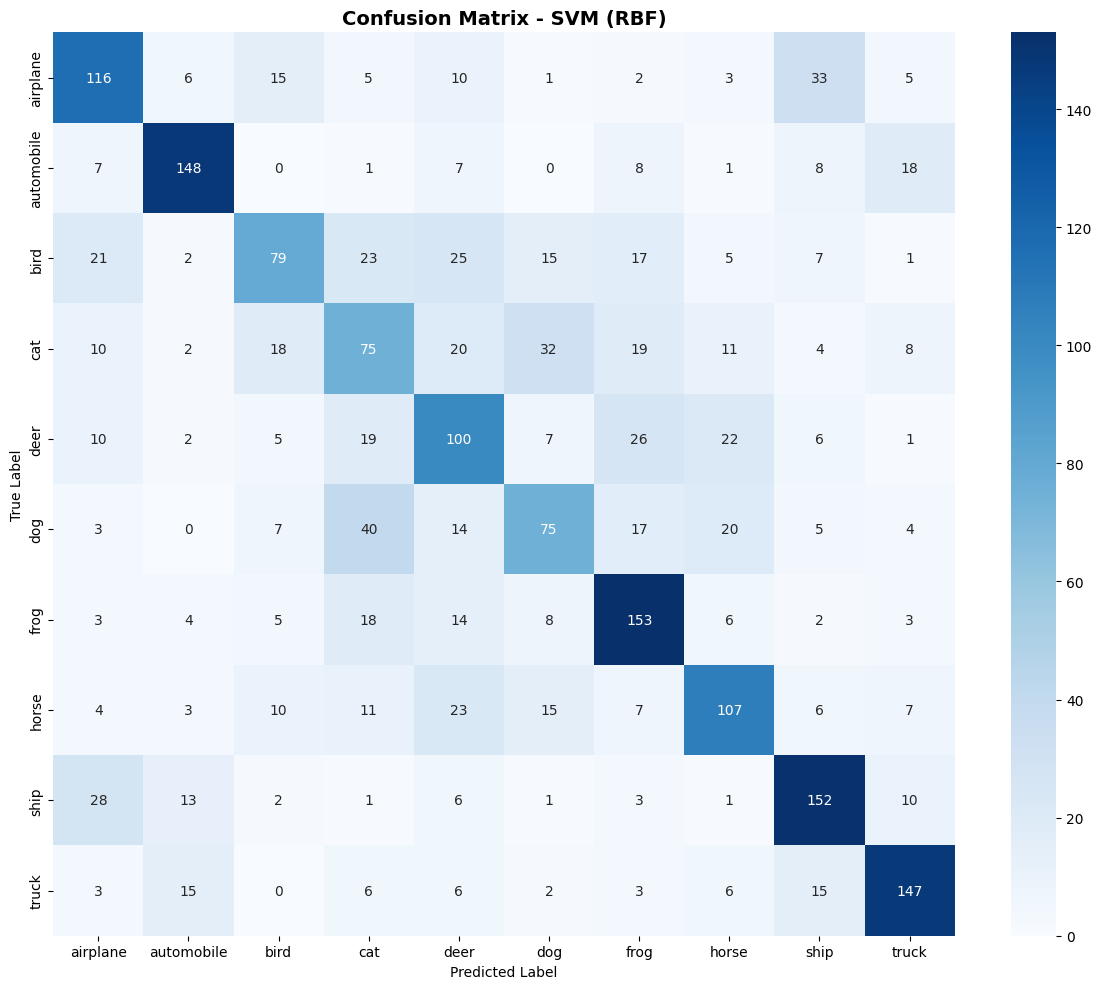

In [10]:
# DETAILED ANALYSIS OF WINNER
print(f"\n{'='*60}")
print(f"🔍 DETAILED ANALYSIS OF {best_model_name}")
print(f"{'='*60}")

# Get predictions for best model
best_model = models[best_model_name]
y_pred_best = predictions[best_model_name]

# Confusion matrix
cm = confusion_matrix(y_test_small, y_pred_best)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# PRINT CLASSIFICATION REPORT
print("\n" + "="*70)
print("📋 CLASSIFICATION REPORT")
print("="*70)

report = classification_report(y_test_small, y_pred_best,
                              target_names=class_names, output_dict=True)

# Print in nice format
for i, class_name in enumerate(class_names):
    print(f"\n{class_name.upper()}:")
    print(f"  Precision: {report[class_name]['precision']:.3f}")
    print(f"  Recall: {report[class_name]['recall']:.3f}")
    print(f"  F1-Score: {report[class_name]['f1-score']:.3f}")

print(f"\n{'='*70}")
print(f"Overall Accuracy: {report['accuracy']:.3f} ({report['accuracy']*100:.2f}%)")
print(f"{'='*70}")


📋 CLASSIFICATION REPORT

AIRPLANE:
  Precision: 0.566
  Recall: 0.592
  F1-Score: 0.579

AUTOMOBILE:
  Precision: 0.759
  Recall: 0.747
  F1-Score: 0.753

BIRD:
  Precision: 0.560
  Recall: 0.405
  F1-Score: 0.470

CAT:
  Precision: 0.377
  Recall: 0.377
  F1-Score: 0.377

DEER:
  Precision: 0.444
  Recall: 0.505
  F1-Score: 0.473

DOG:
  Precision: 0.481
  Recall: 0.405
  F1-Score: 0.440

FROG:
  Precision: 0.600
  Recall: 0.708
  F1-Score: 0.650

HORSE:
  Precision: 0.588
  Recall: 0.554
  F1-Score: 0.571

SHIP:
  Precision: 0.639
  Recall: 0.700
  F1-Score: 0.668

TRUCK:
  Precision: 0.721
  Recall: 0.724
  F1-Score: 0.722

Overall Accuracy: 0.576 (57.60%)


In [12]:
# CROSS VALIDATION
print("\n🔄 Performing 5-fold cross-validation...")
cv_scores = cross_val_score(best_model, X_train_pca, y_train_small, cv=5)

print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Standard deviation: {cv_scores.std()*100:.2f}%")


🔄 Performing 5-fold cross-validation...

Cross-validation scores: [0.5615 0.581  0.566  0.558  0.5745]
Mean CV accuracy: 56.82%
Standard deviation: 0.85%


In [13]:
# FEATURE IMPORTANCE (only if Random Forest is best)
if 'Random Forest' in best_model_name:
    print("\n📊 Analyzing feature importance...")
    importances = best_model.feature_importances_

    plt.figure(figsize=(12, 6))
    indices = np.argsort(importances)[::-1][:20]
    plt.bar(range(20), importances[indices])
    plt.title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance Score')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Feature importance chart saved")
else:
    print(f"\nNote: Feature importance only available for Random Forest")
    print(f"(Best model is {best_model_name})")


Note: Feature importance only available for Random Forest
(Best model is SVM (RBF))


In [14]:
# SAVE EVERYTHING
import joblib
import pickle

print("💾 Saving models and results...")

# Create folder
!mkdir -p /content/drive/MyDrive/ml_project/

# Save models
joblib.dump(best_model, '/content/drive/MyDrive/ml_project/best_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/ml_project/scaler.pkl')
joblib.dump(pca, '/content/drive/MyDrive/ml_project/pca.pkl')

# Save results
results_df.to_csv('/content/drive/MyDrive/ml_project/results.csv', index=False)

# Save the notebook to Drive
!cp '/content/01_ML_Image_Classification.ipynb' '/content/drive/MyDrive/ml_project/'

print("\n✅ ALL FILES SAVED TO GOOGLE DRIVE")
print("📁 Location: /content/drive/MyDrive/ml_project/")
print("\nFiles saved:")
print("  • best_model.pkl (the winning model)")
print("  • scaler.pkl (for scaling new images)")
print("  • pca.pkl (for reducing dimensions)")
print("  • results.csv (performance comparison)")
print("  • model_comparison.png (accuracy chart)")
print("  • confusion_matrix.png (detailed results)")
if 'Random Forest' in best_model_name:
    print("  • feature_importance.png (important features)")

💾 Saving models and results...
cp: cannot stat '/content/01_ML_Image_Classification.ipynb': No such file or directory

✅ ALL FILES SAVED TO GOOGLE DRIVE
📁 Location: /content/drive/MyDrive/ml_project/

Files saved:
  • best_model.pkl (the winning model)
  • scaler.pkl (for scaling new images)
  • pca.pkl (for reducing dimensions)
  • results.csv (performance comparison)
  • model_comparison.png (accuracy chart)
  • confusion_matrix.png (detailed results)


In [15]:
# DOWNLOAD TO COMPUTER
from google.colab import files

# Create zip of all files
!zip -r ml_project_complete.zip /content/drive/MyDrive/ml_project/

# Download
files.download('ml_project_complete.zip')

print("✅ ZIP file downloaded to your computer!")
print("Check your Downloads folder for 'ml_project_complete.zip'")

  adding: content/drive/MyDrive/ml_project/ (stored 0%)
  adding: content/drive/MyDrive/ml_project/best_model.pkl (deflated 13%)
  adding: content/drive/MyDrive/ml_project/scaler.pkl (deflated 6%)
  adding: content/drive/MyDrive/ml_project/pca.pkl (deflated 5%)
  adding: content/drive/MyDrive/ml_project/results.csv (deflated 26%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ ZIP file downloaded to your computer!
Check your Downloads folder for 'ml_project_complete.zip'
